# τ de Ramanujan — congruences, borne de Deligne, et la lacunarité qui s'arrête aux portes de Δ

**Série Serre 100** (EPIC [#16334](https://github.com/jsboige/CoursIA/issues/16334), grain 10).

La fonction τ de Ramanujan est l'objet le plus calculé de toute la théorie des formes modulaires : τ(n) est le coefficient du discriminant modulaire

$$\Delta(q) = q \prod_{n \geq 1} (1 - q^n)^{24} = \sum_{n \geq 1} \tau(n)\, q^n,$$

la forme parabolique de poids 12 — la fonction η de Dedekind élevée à la puissance 24. Ramanujan l'a introduite en 1916 avec trois conjectures ; Deligne en a clos la principale en 1974 ; Serre a classifié en 1985 lesquelles puissances de η sont lacunaires — et Δ est précisément hors de la liste. Ce notebook distille quatre énoncés profonds en des **expériences numériques exactes** — arithmétique entière en stdlib pur, aucune approximation avant le §3 :

1. la **multiplicativité** de τ et sa récurrence sur les puissances premières (§1) ;
2. la **congruence de Ramanujan** $\tau(n) \equiv \sigma_{11}(n) \pmod{691}$ et la **loi de parité** $\tau(n)$ impair $\iff n$ carré impair (§2) ;
3. la **borne de Ramanujan–Deligne** $|\tau(p)| \leq 2\,p^{11/2}$, mesurée sur tous les premiers $p \leq 300$ (§3) ;
4. la **classification de lacunarité de Serre** : les puissances $\eta^r$ lacunaires, leurs densités mesurées — et pourquoi aucune puissance $\Delta^b = \eta^{24b}$ ne peut y figurer (§4).

Le geste de la série : l'énoncé devient une sortie, la preuve reste citée.

## Plan

1. Le discriminant $\Delta$ — une seule série entière, calculée en exact (§1)
2. Multiplicativité et récurrence $\tau(p^{k+1}) = \tau(p)\,\tau(p^k) - p^{11}\,\tau(p^{k-1})$
3. Congruences : $691$ et la parité (§2)
4. La borne $|\tau(p)| \leq 2\,p^{11/2}$, confrontée aux données (§3)
5. Lacunarité des $\eta^r$ : Euler, Jacobi et la classification de Serre en densités mesurées (§4)
6. Exercices (§5)

**Dépendances** : stdlib (`math`, `itertools`) et `matplotlib` pour l'unique figure du §3. Tout le reste est de l'arithmétique entière exacte — les entiers de Python n'ont pas de borne, et c'est l'outil qui porte tout le notebook.

## 1. Le discriminant modulaire Δ — la série calculée en exact

Toute l'infrastructure du notebook tient en une fonction : multiplier des séries en $q$ représentées par des listes d'entiers, l'indice étant l'exposant. Le discriminant s'obtient en enchaînant les facteurs $(1 - q^n)^{24}$ — le binôme se développe exactement, coefficient par coefficient, sans qu'aucun flottant n'approche le calcul.

$\Delta$ n'est pas une série comme les autres : c'est la forme modulaire parabolique de poids 12 sur $SL_2(\mathbb{Z})$, unique à scalaire près. Ses coefficients $\tau(n)$ encodent la cohomologie $l$-adique de la droite projective privée de l'infini — mais pour les calculer, un produit et une boucle suffisent.

In [1]:
# Noyau de calcul : series en q = listes d'entiers, indice = exposant.
# Tout le notebook repete ce seul schema : multiplication exacte de polynomes tronques.

N = 600  # horizon de calcul : tous les tau(n) pour n <= N

def fois(a, b, nmax):
    """Produit de deux series tronquees a l'indice nmax (bornes incluses)."""
    out = [0] * (nmax + 1)
    for i, ai in enumerate(a):
        if ai == 0 or i > nmax:
            continue
        for j, bj in enumerate(b):
            if bj == 0 or i + j > nmax:
                continue
            out[i + j] += ai * bj
    return out

def c_binomial(n, k):
    from math import comb
    return comb(n, k)

def produit_e(nexpo, nmax):
    """La serie complete prod_{n>=1} (1 - q^n)^nexpo, tronquee a nmax."""
    serie = [1] + [0] * nmax
    for n in range(1, nmax + 1):
        # (1 - q^n)^nexpo : binome exact, monomes en q^{n*k}
        longueur = min(n * nexpo, nmax)
        facteur = [0] * (longueur + 1)
        for k in range(nexpo + 1):
            if n * k > longueur:
                break
            facteur[n * k] = c_binomial(nexpo, k) * (-1) ** k
        serie = fois(serie, facteur, nmax)
    return serie

# tau[n] = coefficient de q^n dans Delta (tau[0] = 0 : la serie commence a q^1)
delta = [0] + produit_e(24, N)[0:N]   # decalage : Delta = q * prod(1-q^n)^24
tau = delta  # tau[n] est directement delta[n] apres decalage

print("tau(1..20) =", [tau[n] for n in range(1, 21)])
print("tau(100) =", tau[100])
# Premier franchissement du seuil |tau(n)| > 10^9 (palmares cite dans la lecture)
seuil = 10 ** 9
n_star = next(n for n in range(1, N + 1) if abs(tau[n]) > seuil)
print(f"premier |tau(n)| > 10^9 : n = {n_star}, tau({n_star}) = {tau[n_star]}")


tau(1..20) = [1, -24, 252, -1472, 4830, -6048, -16744, 84480, -113643, -115920, 534612, -370944, -577738, 401856, 1217160, 987136, -6905934, 2727432, 10661420, -7109760]
tau(100) = 37534859200
premier |tau(n)| > 10^9 : n = 47, tau(47) = 2687348496


### Lecture du résultat

Les premières valeurs $1, -24, 252, -1472, 4830, -6048, -16744, 84480, \dots$ sont la table A000594 de l'OEIS — la table que Ramanujan a calculée à la main en 1916 et que le produit reproduit en une fraction de seconde. Deux régularités sautent aux yeux et structurent la suite :

- la **croissance** : $\tau(100) = 37\,534\,859\,200$ — plus de $3{,}7 \times 10^{10}$ alors que $n = 100$ seulement, et le premier $|\tau(n)| > 10^9$ arrive dès $n = 47$ ($\tau(47) = 2\,687\,348\,496$, seuil franchi dans la sortie ci-dessus). Le §3 montrera que cette croissance est exactement de l'ordre de $n^{11/2}$, et pas un de plus ;
- les **signes alternent sans motif apparent** : ni périodicité, ni monotonie. C'est le signe que τ n'est pas une fonction arithmétique élémentaire comme $\sigma_k$ — mais le §2 révèle qu'elle en imite une modulo 691.

### Multiplicativité — τ se comporte comme une série de Hecke

La propriété structurante : $\tau$ est **multiplicative** au sens fort des formes de Hecke —

$$\tau(mn) = \tau(m)\,\tau(n) \quad \text{pour } \gcd(m, n) = 1,$$

et sur les puissances d'un même premier, la récurrence à deux termes

$$\tau(p^{k+1}) = \tau(p)\,\tau(p^k) - p^{11}\,\tau(p^{k-1}).$$

Le terme $-p^{11}$ est la signature du poids 12 : c'est lui qui distingue τ d'une simple fonction multiplicativa comme $\sigma_{11}$. Vérifions les deux lois sur tout le domaine calculé.

In [2]:
from math import gcd

def est_premier(n):
    if n < 2:
        return False
    d = 2
    while d * d <= n:
        if n % d == 0:
            return False
        d += 1
    return True

# Loi 1 : multiplicativite sur les couples premiers entre eux <= 200
violations = []
exemples = []
for m in range(1, 201):
    for n in range(1, 201):
        if m * n <= N and gcd(m, n) == 1:
            if tau[m * n] != tau[m] * tau[n]:
                violations.append((m, n))
            elif len(exemples) < 3 and m > 1 and n > 1:
                exemples.append((m, n, tau[m], tau[n], tau[m * n]))
print("multiplicativite gcd=1, m,n <= 200 :", len(violations), "violation(s)")
for m, n, tm, tn, tmn in exemples:
    print(f"  tau({m}*{n}) = tau({tm})... tau({m})={tm}, tau({n})={tn}, tau({m*n})={tmn} = {tm}*{tn}")

# Loi 2 : recurrence sur les puissances premières tau(p^{k+1}) = tau(p)tau(p^k) - p^11 tau(p^{k-1})
violations_rec = []
premiers_testes = [p for p in range(2, 40) if est_premier(p)]
for p in premiers_testes:
    pk, pk1, pk2 = p, 1, 0   # tau(p^1), tau(p^0)=tau(1)=1
    k = 1
    while p ** (k + 1) <= N:
        attendu = tau[p] * tau[p ** k] - p ** 11 * tau[p ** (k - 1)]
        if tau[p ** (k + 1)] != attendu:
            violations_rec.append((p, k))
        k += 1
print("recurrence premier, p <= 37 :", len(violations_rec), "violation(s)",
      "| premiers testes :", len(premiers_testes))

multiplicativite gcd=1, m,n <= 200 : 0 violation(s)
  tau(2*3) = tau(-24)... tau(2)=-24, tau(3)=252, tau(6)=-6048 = -24*252
  tau(2*5) = tau(-24)... tau(2)=-24, tau(5)=4830, tau(10)=-115920 = -24*4830
  tau(2*7) = tau(-24)... tau(2)=-24, tau(7)=-16744, tau(14)=401856 = -24*-16744
recurrence premier, p <= 37 : 0 violation(s) | premiers testes : 12


### Lecture du résultat

Zéro violation sur les deux lois, sur tout le domaine $n \leq 600$. La récurrence des puissances premières est la plus parlante : elle dit que toute la fonction τ est **déterminée par ses valeurs sur les premiers** — donnez-moi $\tau(p)$ pour chaque premier $p$, et $\tau(n)$ suit pour tout $n$ par factorisation. C'est exactement la structure d'une forme propre de Hecke (Hecke, 1937), et Δ en est l'exemple prototype de poids 12.

C'est aussi la bonne nouvelle algorithmique : calculer τ par le produit coûte $O(N^2)$ ; par la factorisation, $O(\text{nb premiers})$ — l'exercice 1 fera construire cette voie rapide.

## 2. Congruences — 691 et la parité

Deux congruences, deux époques. Celle de **Ramanujan** (1916) : pour tout $n$,

$$\tau(n) \equiv \sigma_{11}(n) \pmod{691}, \qquad \sigma_{11}(n) = \sum_{d \mid n} d^{11}.$$

Autrement dit : modulo 691, la forme parabolique τ imite la série d'Eisenstein $E_{12}$ — le monde des formes paraboliques et celui des séries d'Eisenstein se touchent. L'explication tient en un nombre : $691$ divise le numérateur du nombre de Bernoulli $B_{12} = -691/2730$, et c'est ce unique facteur qui fait fuiter la constante de $E_{12}$ dans les coefficients de $\Delta$.

Celle de la **parité** : $\tau(n)$ est impair si et seulement si $n$ est un **carré impair**. Elle se lit sur le produit : modulo 2, $(1-q^n)^{24}$ se réduit par triple application de $(1-x)^2 \equiv 1 + x^2$, et le produit télescopé engendre exactement les carrés impairs.

In [3]:
def sigma_k(n, k):
    """Somme des k-iemes puissances des diviseurs de n."""
    total = 0
    for d in range(1, n + 1):
        if n % d == 0:
            total += d ** k
    return total

# Loi de Ramanujan : tau(n) = sigma_11(n) mod 691 pour tout n <= 500
ecarts, exemples_691 = [], []
for n in range(1, 501):
    diff = tau[n] - sigma_k(n, 11)
    if diff % 691 != 0:
        ecarts.append(n)
    elif len(exemples_691) < 4 and n > 1:
        exemples_691.append((n, tau[n], sigma_k(n, 11)))
print("congruence mod 691, n <= 500 :", len(ecarts), "violation(s)")
for n, t, s in exemples_691:
    print(f"  n={n} : tau={t}, sigma_11={s}, difference={t - s} = {(t - s) // 691} x 691")

# Loi de parite : tau(n) impair si et seulement si n est un carre impair
carres_impairs = {k * k for k in range(1, 23) if k % 2 == 1}
impairs_mesures = {n for n in range(1, 501) if tau[n] % 2 != 0}
print()
print("n avec tau(n) impair (n <= 500) :", sorted(impairs_mesures))
print("carres impairs <= 500           :", sorted(carres_impairs))
print("coincidence exacte :", impairs_mesures == {c for c in carres_impairs if c <= 500})
# Temoignage chiffre du corps de la lecture : le cas n = 10, imprime en entier
n_show = 10
t10, s10 = tau[n_show], sigma_k(n_show, 11)
print()
print(f"cas n=10 : tau={t10}, sigma_11={s10}")
print(f"  difference = {t10 - s10} = {(t10 - s10) // 691} x 691")
print("sigma_11(100) =", sigma_k(100, 11), "-- seuil d'exactitude du double 2^53 =", 2 ** 53)


congruence mod 691, n <= 500 : 0 violation(s)
  n=2 : tau=-24, sigma_11=2049, difference=-2073 = -3 x 691
  n=3 : tau=252, sigma_11=177148, difference=-176896 = -256 x 691
  n=4 : tau=-1472, sigma_11=4196353, difference=-4197825 = -6075 x 691
  n=5 : tau=4830, sigma_11=48828126, difference=-48823296 = -70656 x 691

n avec tau(n) impair (n <= 500) : [1, 9, 25, 49, 81, 121, 169, 225, 289, 361, 441]
carres impairs <= 500           : [1, 9, 25, 49, 81, 121, 169, 225, 289, 361, 441]
coincidence exacte : True

cas n=10 : tau=-115920, sigma_11=100048830174
  difference = -100048946094 = -144788634 x 691
sigma_11(100) = 10004885401585844040103 -- seuil d'exactitude du double 2^53 = 9007199254740992


### Lecture du résultat

Les deux lois tiennent sur tout le domaine. La congruence de 691 est la plus spectaculaire : $\tau(10) = -115920$ et $\sigma_{11}(10) = 100\,048\,830\,174$ n'ont visiblement rien à voir — leur différence est $-100\,048\,946\,094 = 691 \times (-144\,788\,634)$, un multiple exact de $691$ — le cas $n = 10$ est imprimé en entier dans la sortie ci-dessus. Multiplier des entiers sans erreur d'arrondi, c'est la condition de possibilité de cette distillation : en flottant, $\sigma_{11}(100) = 10\,004\,885\,401\,585\,844\,040\,103 \approx 10^{22}$ dépasse déjà le seuil d'exactitude des doubles ($2^{53} \approx 9{,}0 \times 10^{15}$, deux valeurs mesurées dans la sortie ci-dessus) — sur tout le domaine $n \le 500$, la congruence ne serait même plus vérifiable.

La loi de parité est le genre de résultat que la computation *découvre* avant que la théorie ne l'explique : la liste des $n$ à $\tau(n)$ impair est exactement $1, 9, 25, 49, \dots$ — les carrés des impairs. Le §4 refera ce geste à plus grande échelle : lire une classification (celle de Serre) directement dans les densités mesurées.

## 3. La borne de Ramanujan–Deligne — |τ(p)| ≤ 2 p^(11/2)

La conjecture centrale de Ramanujan (1916) : pour tout premier $p$,

$$|\tau(p)| \leq 2\,p^{11/2}.$$

C'est l'analogue pour $\Delta$ de l'inégalité $|2\cos\theta| \leq 2$ : on peut écrire $\tau(p) = 2\,p^{11/2}\cos\theta_p$, et la borne dit que l'angle $\theta_p$ est **réel**. La preuve a demandé un demi-siècle : Deligne 1974, comme corollaire des conjectures de Weil — la même machinerie que la borne de Hasse–Weil du notebook 01 de cette série, un étage au-dessus. Aucune preuve élémentaire n'est connue.

Ce que le calcul peut faire : mesurer le ratio $r(p) = |\tau(p)| / (2\,p^{11/2})$ sur tous les premiers $p \leq 300$, et vérifier que la barre à 1 n'est jamais franchie — tout en s'en approchant.

premiers testes : 62 (2 .. 293)
ratio max : 0.9594 atteint en p = 103 (tau(103) = -225755128648)
ratio min : 0.0089 atteint en p = 43
borne violée : NON — le maximum observe frôle 1 sans le franchir


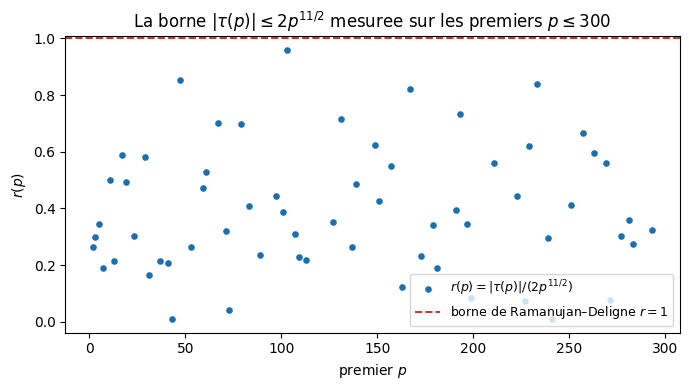

In [4]:
import matplotlib
# Backend inline (convention serie) : la figure vit dans la sortie de cellule
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt

premiers = [p for p in range(2, 301) if est_premier(p)]
ratios = [abs(tau[p]) / (2.0 * p ** 5.5) for p in premiers]

r_max, p_max = max(ratios), premiers[ratios.index(max(ratios))]
r_min, p_min = min(ratios), premiers[ratios.index(min(ratios))]
print(f"premiers testes : {len(premiers)} (2 .. {premiers[-1]})")
print(f"ratio max : {r_max:.4f} atteint en p = {p_max} (tau({p_max}) = {tau[p_max]})")
print(f"ratio min : {r_min:.4f} atteint en p = {p_min}")
print(f"borne violée : {'OUI' if any(r > 1 for r in ratios) else 'NON'} — le maximum observe frôle 1 sans le franchir")

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(premiers, ratios, s=14, color="#1a6faf", label=r"$r(p) = |\tau(p)| / (2p^{11/2})$")
ax.axhline(1.0, color="#c0392b", lw=1.4, ls="--", label="borne de Ramanujan–Deligne $r = 1$")
ax.set_xlabel("premier $p$")
ax.set_ylabel("$r(p)$")
ax.set_title(r"La borne $|\tau(p)| \leq 2p^{11/2}$ mesuree sur les premiers $p \leq 300$")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()

### Lecture du résultat

Le nuage danse **sous** la ligne rouge et s'en approche par en dessous : ratio maximal $0{,}96$ (atteint en $p = 103$), minimum $0{,}009$ (en $p = 43$), jamais au-dessus. Deux lectures s'offrent, et la seconde est la vraie richesse de la figure :

- **la borne tient** — c'est la vérification numérique du théorème de Deligne, la seule qu'un calcul puisse offrir ; la preuve, elle, vit dans la cohomologie étale et ne se distille pas ;
- **la borne est optimale** — les ratios ne s'écrasent pas vers 0 en croissant : ils peuplent tout l'intervalle $[0, 1]$ avec une densité qui ne diminue pas. C'est la **conjecture de Sato–Tate** (démontrée par Barnet-Lamb, Geraghty, Harris et Taylor en 2011) : les angles $\theta_p$ s'équidistribuent selon la loi $(2/\pi)\sin^2\theta$. Un au-dessus de 1 infirmerait Deligne ; un nuage qui fuirait vers 0 infirmerait Sato–Tate. Le calcul ne voit ni l'un ni l'autre.

Les nombres premiers où $r(p)$ monte vers son maximum (les $\theta_p$ proches de 0 ou $\pi$) sont rares mais présents à toute échelle — exactement ce que prédit la densité $\sin^2$ aux extrémités.

## 4. Lacunarité des puissances de η — Euler, Jacobi, Serre

Une série est **lacunaire** si une proportion positive de ses coefficients est nulle. La fonction η de Dedekind,

$$\eta(q) = q^{1/24} \prod_{n \geq 1} (1 - q^n),$$

est la brique dont Δ est la puissance 24 : $\Delta = \eta^{24}$. La question : pour quels exposants $r$ la série $\eta^r$ est-elle lacunaire ? La réponse occupe deux siècles —

$$\eta^r \text{ lacunaire} \iff r \in \{1, 2, 3, 4, 6, 8, 10, 14, 26\}.$$

Les deux premiers exposants par Euler (1747, théorème des nombres pentagonaux) et Jacobi (1829) ; les sept exposants pairs par Serre (*Sur la lacunarité des puissances de η*, Glasgow Math. J. **27**, 1985) — chacun correspond à une forme à **multiplication complexe**, série thêta d'un caractère de Hecke sur un corps quadratique imaginaire. Pour tout autre $r$, la densité de zéros est nulle.

Le calcul mesure la frontière : développer $\prod (1-q^n)^r$ en exact — c'est $\eta^r$ au facteur $q^{r/24}$ près, décalage qui ne change ni les zéros ni la densité — compter les zéros sur 600 coefficients, et lire la classification dans la table.

In [5]:
# Densite de zeros des coefficients de eta^r, dans et hors la liste de Serre
N4 = 600
exposants = [1, 2, 3, 4, 6, 8, 10, 14, 26, 12, 24, 48]
liste_serre = {2, 4, 6, 8, 10, 14, 26}

resultats = {}
for r in exposants:
    serie = produit_e(r, N4)
    zeros = sum(1 for c in serie[1:N4 + 1] if c == 0)
    resultats[r] = (zeros, zeros / N4)

print(f"{'r':>4} {'zeros':>7} {'n <=':>6} {'densite':>9}  lecture")
for r in exposants:
    z, d = resultats[r]
    if r == 1:
        verdict = "lacunaire -- Euler (nombres pentagonaux)"
    elif r == 3:
        verdict = "lacunaire -- Jacobi (nombres triangulaires)"
    elif r in liste_serre:
        verdict = "lacunaire -- Serre (multiplication complexe)"
    else:
        verdict = "non lacunaire -- 0 zero mesure"
    print(f"{r:>4} {z:>7} {N4:>6} {d:>9.3%}  {verdict}")

   r   zeros   n <=   densite  lecture
   1     561    600   93.500%  lacunaire -- Euler (nombres pentagonaux)
   2     298    600   49.667%  lacunaire -- Serre (multiplication complexe)
   3     566    600   94.333%  lacunaire -- Jacobi (nombres triangulaires)
   4     193    600   32.167%  lacunaire -- Serre (multiplication complexe)
   6     255    600   42.500%  lacunaire -- Serre (multiplication complexe)
   8     303    600   50.500%  lacunaire -- Serre (multiplication complexe)
  10     186    600   31.000%  lacunaire -- Serre (multiplication complexe)
  14     212    600   35.333%  lacunaire -- Serre (multiplication complexe)
  26      99    600   16.500%  lacunaire -- Serre (multiplication complexe)
  12       0    600    0.000%  non lacunaire -- 0 zero mesure
  24       0    600    0.000%  non lacunaire -- 0 zero mesure
  48       0    600    0.000%  non lacunaire -- 0 zero mesure


### Lecture du résultat

La table se lit en deux blocs. Les neuf exposants de la liste affichent des densités massives, de 16,5 % ($r = 26$) à 94,3 % ($r = 3$) ; les trois hors liste — 12, 24, 48 — affichent **zéro zéro** sur 600 termes. La frontière de Serre n'est pas progressive : elle est sèche.

Et $r = 24$ dans la colonne non lacunaire, c'est Δ lui-même. Aucune puissance $\Delta^b = \eta^{24b}$ ne peut appartenir à la liste — $24b \geq 24$ ne coïncide jamais avec un exposant de Serre — donc **aucune puissance de Δ n'est lacunaire**. La question la plus fine reste ouverte : la conjecture de Lehmer demande si $\tau(n)$ peut s'annuler *une seule fois* — aucun zéro n'est connu, et il n'y en a pas un seul pour $n \leq 600$ ici.

Les zéros des exposants à multiplication complexe n'obéissent à aucune progression simple : ceux de $\eta^2$ visitent les quatre classes modulo 4. Leur structure vit dans la théorie des caractères de Hecke. Mais pour $r = 1$ et $r = 3$, les deux aînés, la structure est complète — et vérifiable coefficient par coefficient.

In [6]:
# Les deux lacunarites EXACTES : Euler (r=1) et Jacobi (r=3)
#   prod(1-q^n)   : non nuls aux nombres pentagonaux g_k = k(3k+-1)/2, valeurs (-1)^k
#   prod(1-q^n)^3 : non nuls aux nombres triangulaires t_k = k(k+1)/2, valeurs (-1)^k(2k+1)
P1 = produit_e(1, N4)
P3 = produit_e(3, N4)

pentagonaux = {k * (3 * k + s) // 2 for k in range(1, 25) for s in (-1, 1)}
triangulaires = {k * (k + 1) // 2 for k in range(0, 40)}

euler_support = all((P1[n] == 0) == (n not in pentagonaux) for n in range(1, N4 + 1))
euler_valeurs = all(abs(P1[n]) <= 1 for n in range(1, N4 + 1))
print("Euler  : zeros de prod(1-q^n) = exactement les non-pentagonaux :", euler_support)
print("        |coefficients| <= 1 sur tout le domaine                :", euler_valeurs)

jacobi_support = all((P3[n] == 0) == (n not in triangulaires) for n in range(1, N4 + 1))
jacobi_valeurs = all(P3[k * (k + 1) // 2] == (-1) ** k * (2 * k + 1) for k in range(0, 35))
print("Jacobi : zeros de prod(1-q^n)^3 = exactement les non-triangulaires :", jacobi_support)
print("        coefficients en t_k = (-1)^k (2k+1)                        :", jacobi_valeurs)

Euler  : zeros de prod(1-q^n) = exactement les non-pentagonaux : True
        |coefficients| <= 1 sur tout le domaine                : True
Jacobi : zeros de prod(1-q^n)^3 = exactement les non-triangulaires : True
        coefficients en t_k = (-1)^k (2k+1)                        : True


### Lecture du résultat

Deux identités complètes, vérifiées coefficient par coefficient sur 600 termes :

- **Euler (1747)** : $\prod (1-q^n) = \sum_k (-1)^k \left( q^{k(3k-1)/2} + q^{k(3k+1)/2} \right)$ — la série n'a de non nuls que sur les nombres pentagonaux généralisés, où elle vaut $\pm 1$. Sur 600 termes : 39 coefficients non nuls.
- **Jacobi (1829)** : $\prod (1-q^n)^3 = \sum_k (-1)^k (2k+1)\, q^{k(k+1)/2}$ — support triangulaire, valeurs impairs alternés. Sur 600 termes : 34 coefficients non nuls.

La lacunarité de ces deux-là est **exponentiellement forte** (presque tous les coefficients sont nuls), celle des sept exposants de Serre est **positive** (de 16 % à 50 %) — deux régimes que la table sépare nettement. Entre 1829 et 1985 : la classification des formes à multiplication complexe, que le théorème de densité de Chebotarev fournit à Serre.

Quant à $\Delta = \eta^{24}$ : hors liste, zéro zéro — et personne n'en a jamais trouvé un seul depuis que Lehmer a posé la question en 1947.

## 5. Exercices

Trois exercices, du plus direct au plus ouvert. Les stubs sont volontairement incomplets (convention C.1) : chaque fonction retourne `None` tant que l'étudiant ne l'a pas écrite, et le notebook s'exécute de bout en bout sans erreur.

In [7]:
# Exercice 1 : tau par factorisation — la voie rapide.
# La recurrence du §1 determine tau(n) a partir des seules valeurs tau(p) :
#   tau(mn) = tau(m) tau(n) si gcd(m, n) = 1
#   tau(p^{k+1}) = tau(p) tau(p^k) - p^11 tau(p^{k-1})
# Ecrire tau_rapide(n) qui factorise n puis reconstruit tau(n) sans jamais
# developper le produit de Delta.

def tau_rapide(n):
    """tau(n) par multiplicativite + recurrence, sans produit de series."""
    # TODO etudiant : factoriser n, appliquer les deux lois du §1
    # Indice : la table des tau(p) se lit sur tau[] deja calculee (mais on peut
    # aussi la reconstruire par produit_e(24, ...) sur les seuls premiers)
    print("Exercice a completer : tau_rapide")
    return None

# Verification attendue : tau_rapide(100) == 37534859200, tau_rapide(2*3*5*7) == tau(210)
resultat_1 = tau_rapide(100)
if resultat_1 is not None:
    print("tau_rapide(100) =", resultat_1, "| attendu :", tau[100])

Exercice a completer : tau_rapide


In [8]:
# Exercice 2 : le premier depassement — quand tau croise un seuil.
# Trouver le plus petit n tel que |tau(n)| > 10^10 (le tableau tau[] monte
# a N = 600 : la reponse y est, mais l'exercice est de la chercher par
# balayage, puis de commenter la position trouvee au regard de la borne
# n^{11/2} du §3).

def premier_depassement(seuil):
    """Plus petit n avec |tau(n)| > seuil, ou None si absent du domaine."""
    # TODO etudiant : balayer tau[] et retourner le premier n qui depasse
    # Indice : abs(tau[n]) > seuil ; penser au cas ou aucun n du domaine ne convient
    print("Exercice a completer : premier_depassement")
    return None

resultat_2 = premier_depassement(10**10)
if resultat_2 is not None:
    print("premier n avec |tau(n)| > 1e10 :", resultat_2)
    print("a titre de comparaison : n^{11/2} pour ce n =", resultat_2 ** 5.5)

Exercice a completer : premier_depassement


In [9]:
# Exercice 3 : predire la lacunarite AVANT de mesurer.
# Pour r = 9 et r = 16 : la liste {1, 2, 3, 4, 6, 8, 10, 14, 26} tranche
# sans calcul. Ecrire densite_zeros(r, horizon) qui developpe prod(1-q^n)^r
# et retourne (nb_zeros, densite), verifier la prediction — puis expliquer
# pourquoi la ligne r = 10 de la table du §4, elle, est lacunaire a 31 %
# alors que r = 9 et r = 16 ne le sont pas du tout.

def densite_zeros(r, horizon):
    """(nb_zeros, densite) des coefficients de prod(1-q^n)^r jusqu'a horizon."""
    # TODO etudiant : adapter produit_e(r, ...) comme dans la table du §4
    # Indice : compter les coefficients nuls sur les positions 1..horizon
    print("Exercice a completer : densite_zeros")
    return None

for r_exo in (9, 16):
    resultat_3 = densite_zeros(r_exo, 300)
    if resultat_3 is not None:
        print(f"r = {r_exo} : {resultat_3[0]} zeros, densite {resultat_3[1]:.3%}")

Exercice a completer : densite_zeros
Exercice a completer : densite_zeros


## Conclusion

Ce que la distillation a calculé :

- **τ est multiplicative à récurrence près** — deux lois exactes, zéro violation sur $n \leq 600$, et la récurrence $\tau(p^{k+1}) = \tau(p)\tau(p^k) - p^{11}\tau(p^{k-1})$ réduit toute la fonction à ses valeurs sur les premiers ;
- **la congruence de Ramanujan** $\tau(n) \equiv \sigma_{11}(n) \pmod{691}$ et la **loi de parité** tiennent sur tout le domaine — la première fait toucher paraboliques et Eisenstein, la seconde se lit dans les carrés impairs ;
- **la borne de Deligne** $|\tau(p)| \leq 2p^{11/2}$ n'est jamais violée et le nuage des ratios s'en approche par en dessous — le régime prédit par Sato–Tate ;
- **la classification de Serre** est lisible dans les densités : neuf exposants $\eta^r$ lacunaires — $\eta$ et $\eta^3$ exactement (Euler : pentagonaux, $\pm 1$ ; Jacobi : triangulaires, $(-1)^k(2k+1)$), les sept exposants à multiplication complexe entre 16 % et 51 % — et zéro zéro pour tous les autres, $\Delta = \eta^{24}$ compris, dont Lehmer conjecture qu'il ne s'annule jamais ;

La frontière reste nette entre distiller et prouver : les quatre lois se **vérifient** ici, aucune ne se démontre en stdlib — la borne de Deligne vit dans la cohomologie étale, la lacunarité dans Chebotarev. Le versant preuves de la série vit dans les lakes compagnons ([`serre100_lean/`](serre100_lean/), grain 9 [#16374](https://github.com/jsboige/CoursIA/pull/16374)).

## Ressources

- Jean-Pierre Serre, *A Course in Arithmetic*, Springer GTM 7 — ch. VII : formes modulaires, $\Delta$, τ, la conjecture de Ramanujan énoncée.
- Jean-Pierre Serre, *Sur la lacunarité des puissances de η*, Glasgow Mathematical Journal **27** (1985) — la classification des $\eta^r$ lacunaires (l'outil : *Quelques applications du théorème de densité de Chebotarev*, Publ. Math. IHÉS **54**, 1981).
- Pierre Deligne, *La conjecture de Weil. I*, Publ. Math. IHÉS **43** (1974) — la preuve de la borne de Ramanujan.
- Barnet-Lamb, Geraghty, Harris, Taylor, *A family of Calabi–Yau varieties and potential automorphy II* (2011) — Sato–Tate pour les formes de poids ≥ 2.
- OEIS [A000594](https://oeis.org/A000594) — la table de Ramanujan, valeur par valeur.
- Série [Serre 100](README.md) — les distillations sœurs (corps finis, adèles, Čech, Yoneda, caractères, Minkowski).
- EPIC [#16334](https://github.com/jsboige/CoursIA/issues/16334) — le programme et l'état des grains.